1) Import + carga de datos

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch


In [3]:
# Rutas robustas (notebooks/ -> root)
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "events.parquet"

assert DATA_PATH.exists(), f"No existe: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH)
df.shape


(187858, 44)

2) Filtrar tiros y sanity checks

In [4]:
shots = df[df["type"] == "Shot"].copy()
shots.shape


(1340, 44)

In [5]:
cols_needed = ["match_id", "team", "player", "x", "y", "shot_outcome", "shot_statsbomb_xg"]
[c for c in cols_needed if c not in shots.columns]


[]

In [6]:
shots["shot_outcome"].value_counts().head(15)


shot_outcome
Off T               397
Blocked             386
Saved               316
Goal                126
Wayward              81
Post                 25
Saved to Post         5
Saved Off Target      4
Name: count, dtype: int64

3) Elegir un partido y equipo

In [7]:
shots["match_id"].value_counts().head(10)


match_id
3942349    44
3942226    42
3941018    39
3938639    36
3941020    36
3930167    35
3930175    34
3942227    34
3938637    33
3938642    32
Name: count, dtype: int64

In [8]:
match_id = int(shots["match_id"].value_counts().index[0])  # el más frecuente
match_id


3942349

In [9]:
s_match = shots[shots["match_id"] == match_id].copy()
s_match["team"].value_counts()


team
France      25
Portugal    19
Name: count, dtype: int64

In [10]:
team_name = s_match["team"].value_counts().index[0]
team_name


'France'

In [11]:
s_team = s_match[s_match["team"] == team_name].copy()
s_team.shape


(25, 44)

4) Definir gol vs no gol + tamaño por xG (Code)

StatsBomb suele tener shot_outcome == "Goal" para goles.

In [12]:
s_team["is_goal"] = s_team["shot_outcome"].eq("Goal")

# xG (rellena NaN con 0 por seguridad)
s_team["xg"] = pd.to_numeric(s_team["shot_statsbomb_xg"], errors="coerce").fillna(0.0)

s_team[["is_goal", "xg"]].describe()


,xg
count,25.000000
mean,0.199396
std,0.302869
min,0.006239
25%,0.021160
50%,0.048120
75%,0.185620
max,0.783500


In [13]:
# Ajusta el multiplicador si te quedan muy grandes/pequeños
s_team["marker_size"] = 50 + (s_team["xg"] * 500)
s_team[["xg", "marker_size"]].describe()


,xg,marker_size
count,25.000000,25.000000
mean,0.199396,149.698111
std,0.302869,151.434546
min,0.006239,53.119732
25%,0.021160,60.580041
50%,0.048120,74.060225
75%,0.185620,142.810245
max,0.783500,441.750000


5) Shot map del equipo (gol vs no gol)

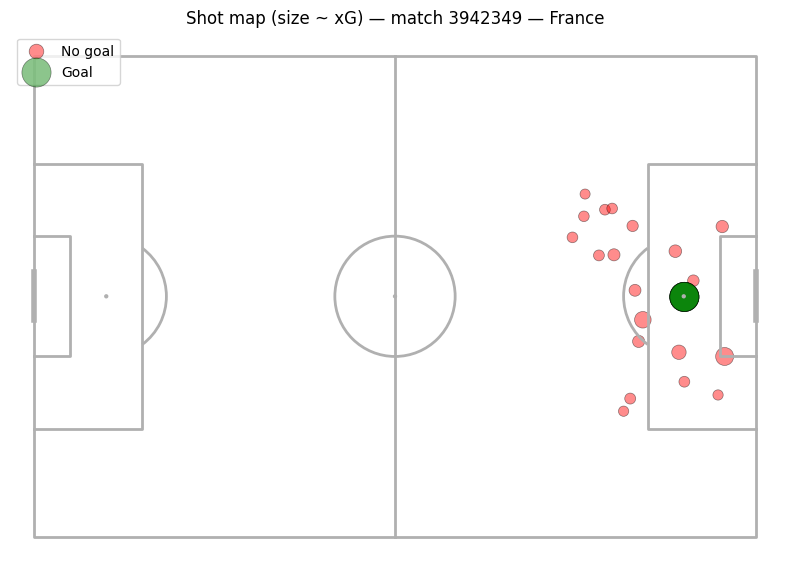

In [ ]:
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(8, 8))

goals = s_team[s_team["is_goal"]]
nongoals = s_team[~s_team["is_goal"]]

# no goles (rojo)
pitch.scatter(
    nongoals["x"], nongoals["y"],
    s=nongoals["marker_size"],
    ax=ax,
    alpha=0.45,
    color="red",
    edgecolors="black",
    linewidth=0.5,
    label="No goal"
)

# goles (verde)
pitch.scatter(
    goals["x"], goals["y"],
    s=goals["marker_size"],
    ax=ax,
    alpha=0.45,
    color="green",
    edgecolors="black",
    linewidth=0.5,
    label="Goal"
)

ax.set_title(f"Shot map (size ~ xG) — match {match_id} — {team_name}")
ax.legend(loc="upper left")
plt.show()


6) Shot map por jugador

In [18]:
s_team["player"].value_counts().head(10)


player
Kylian Mbappé Lottin               5
Ousmane Dembélé                    4
Theo Bernard François Hernández    2
Eduardo Camavinga                  2
Aurélien Djani Tchouaméni          2
N'Golo Kanté                       2
Bradley Barcola                    2
Antoine Griezmann                  1
Randal Kolo Muani                  1
Marcus Thuram                      1
Name: count, dtype: int64

In [19]:
player_name = s_team["player"].value_counts().index[0]
player_name


'Kylian Mbappé Lottin'

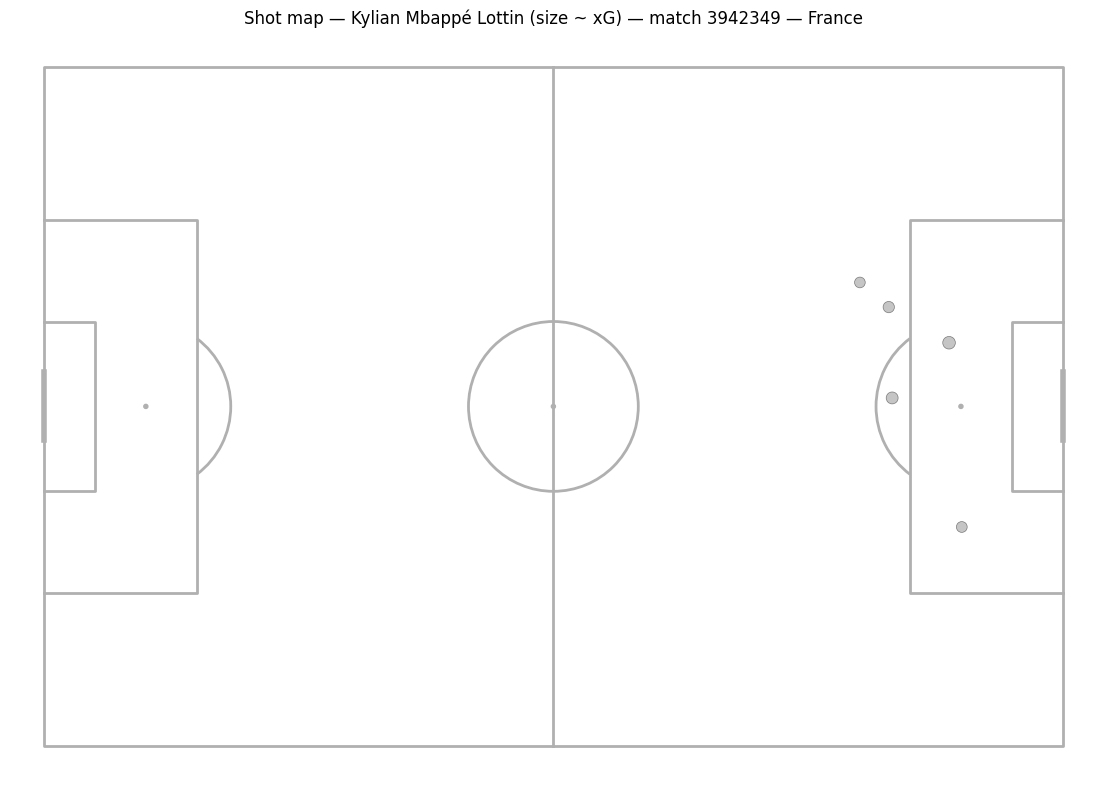

In [20]:
s_player = s_team[s_team["player"] == player_name].copy()

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

goals = s_player[s_player["is_goal"]]
nongoals = s_player[~s_player["is_goal"]]

pitch.scatter(
    nongoals["x"], nongoals["y"],
    s=nongoals["marker_size"],
    ax=ax,
    alpha=0.45,
    color="gray",
    edgecolors="black",
    linewidth=0.5,
)

pitch.scatter(
    goals["x"], goals["y"],
    s=goals["marker_size"],
    ax=ax,
    alpha=0.9,
    color="green",
    edgecolors="black",
    linewidth=0.8,
)

ax.set_title(f"Shot map — {player_name} (size ~ xG) — match {match_id} — {team_name}")
plt.show()


7) Mostrar dirección del tiro con líneas

In [21]:
needed = ["end_x", "end_y"]
[c for c in needed if c not in s_team.columns]


[]

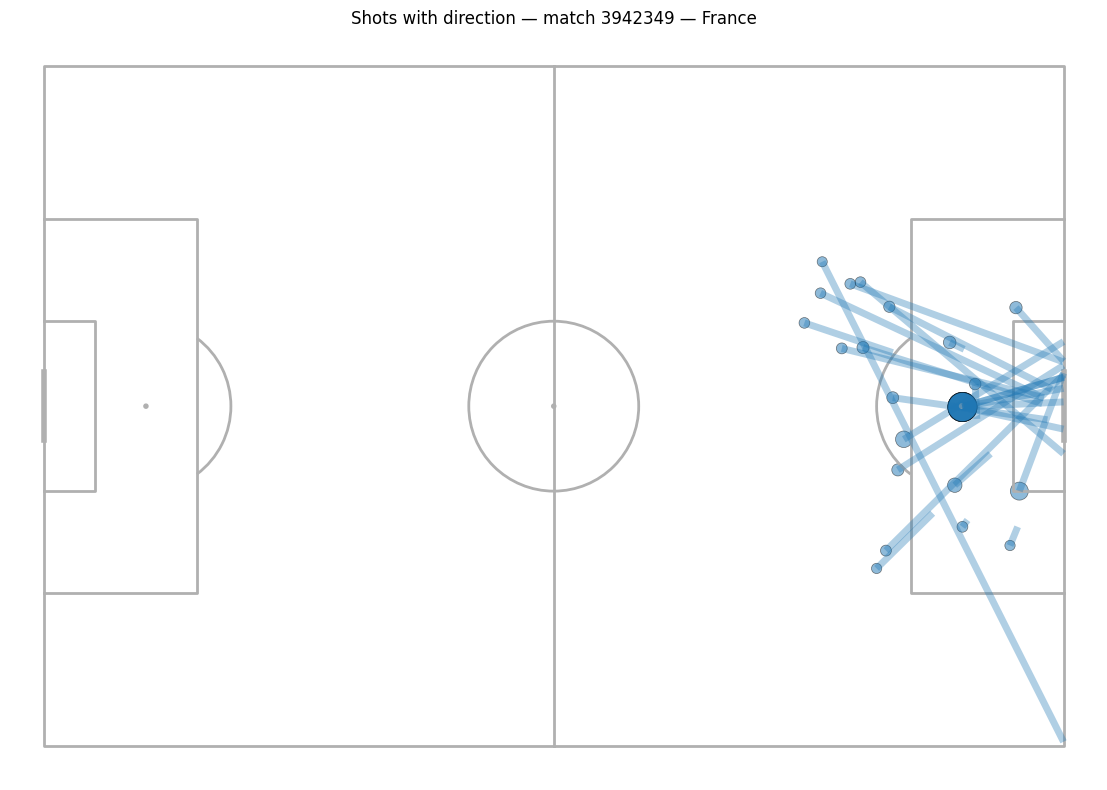

In [22]:
with_end = s_team.dropna(subset=["end_x", "end_y"]).copy()

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

# puntos de tiro
pitch.scatter(
    with_end["x"], with_end["y"],
    s=with_end["marker_size"],
    ax=ax,
    alpha=0.5,
    edgecolors="black",
    linewidth=0.5,
)

# líneas hacia end_location
pitch.lines(
    with_end["x"], with_end["y"],
    with_end["end_x"], with_end["end_y"],
    ax=ax,
    alpha=0.35,
)

ax.set_title(f"Shots with direction — match {match_id} — {team_name}")
plt.show()


8) Chequeos rápidos útiles

Total xG por equipo en ese partido:

In [23]:
s_match.groupby("team")["shot_statsbomb_xg"].sum().sort_values(ascending=False)


team
France      4.984906
Portugal    4.542799
Name: shot_statsbomb_xg, dtype: float64

In [24]:
s_team.groupby("player")["xg"].sum().sort_values(ascending=False).head(10)


player
Ousmane Dembélé                    0.873168
Bradley Barcola                    0.842950
Theo Bernard François Hernández    0.801166
Youssouf Fofana                    0.783500
Jules Koundé                       0.783500
Eduardo Camavinga                  0.257998
Kylian Mbappé Lottin               0.189563
Marcus Thuram                      0.185620
Randal Kolo Muani                  0.116559
N'Golo Kanté                       0.076374
Name: xg, dtype: float64

In [25]:
shots["play_pattern"].value_counts()


play_pattern
Regular Play      433
From Free Kick    243
From Throw In     231
From Corner       222
From Goal Kick     60
From Counter       56
Other              39
From Keeper        37
From Kick Off      19
Name: count, dtype: int64

In [26]:
from pathlib import Path
import pandas as pd

# --- Cargar dataset procesado ---
PROJECT_ROOT = Path.cwd().parent  # asumiendo que el notebook está en /notebooks
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "events.parquet"
assert DATA_PATH.exists(), f"No existe el parquet en: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH)

# --- Filtrar tiros ---
shots = df[df["type"] == "Shot"].copy()

# --- Encontrar el match_id donde juegan France y Portugal ---
matches_fp = (
    shots.groupby("match_id")["team"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="teams")
)

fp_rows = matches_fp[matches_fp["teams"].apply(lambda t: {"France", "Portugal"}.issubset(t))]

if fp_rows.empty:
    raise ValueError(
        "No he encontrado ningún match_id que contenga a la vez 'France' y 'Portugal' en la columna team. "
        "Comprueba los nombres exactos con df['team'].unique()."
    )

match_id = int(fp_rows["match_id"].iloc[0])

# --- Tiros de ese partido ---
shots_fp = shots[shots["match_id"] == match_id].copy()

# --- Separar goles y no goles ---
goals_fp = shots_fp[shots_fp["shot_outcome"] == "Goal"].copy()
missed_fp = shots_fp[shots_fp["shot_outcome"] != "Goal"].copy()

# --- Mostrar resultados ---
print(f"Match ID (France vs Portugal): {match_id}")
print("\nEquipos en el partido:")
print(shots_fp["team"].value_counts())

print("\nDistribución de outcomes:")
print(shots_fp["shot_outcome"].value_counts(dropna=False))

print("\n=== TIROS ACABADOS EN GOL ===")
display(
    goals_fp[[
        "team", "player", "minute", "second", "period",
        "play_pattern", "shot_type", "shot_statsbomb_xg", "x", "y"
    ]].sort_values(["minute", "second"])
)

print("\n=== TIROS NO GOL (fallados / parados / bloqueados / fuera, etc.) ===")
display(
    missed_fp[[
        "team", "player", "minute", "second", "period",
        "play_pattern", "shot_type", "shot_statsbomb_xg", "x", "y"
    ]].sort_values(["minute", "second"])
)


Match ID (France vs Portugal): 3942349

Equipos en el partido:
team
France      25
Portugal    19
Name: count, dtype: int64

Distribución de outcomes:
shot_outcome
Blocked    12
Off T      10
Saved       9
Goal        8
Post        3
Wayward     2
Name: count, dtype: int64

=== TIROS ACABADOS EN GOL ===


,team,player,minute,second,period,play_pattern,shot_type,shot_statsbomb_xg,x,y
174298,France,Ousmane Dembélé,120,3,5,Other,Penalty,0.7835,108.1,40.1
174300,Portugal,Cristiano Ronaldo dos Santos Aveiro,120,59,5,Other,Penalty,0.7835,108.1,40.1
174302,France,Youssouf Fofana,121,51,5,Other,Penalty,0.7835,108.1,40.1
174304,Portugal,Bernardo Mota Veiga de Carvalho e Silva,122,34,5,Other,Penalty,0.7835,108.1,40.1
174306,France,Jules Koundé,123,25,5,Other,Penalty,0.7835,108.1,40.1
174310,France,Bradley Barcola,125,22,5,Other,Penalty,0.7835,108.1,40.1
174312,Portugal,Nuno Mendes,126,22,5,Other,Penalty,0.7835,108.1,40.1
174314,France,Theo Bernard François Hernández,127,16,5,Other,Penalty,0.7835,108.1,40.1



=== TIROS NO GOL (fallados / parados / bloqueados / fuera, etc.) ===


,team,player,minute,second,period,play_pattern,shot_type,shot_statsbomb_xg,x,y
169870,Portugal,Bruno Miguel Borges Fernandes,15,51,1,Regular Play,Open Play,0.027407,92.5,32.9
170016,France,Theo Bernard François Hernández,19,32,1,Regular Play,Open Play,0.017666,91.4,26.7
170348,France,Antoine Griezmann,27,33,1,Regular Play,Open Play,0.009978,98.0,59.1
170362,France,Eduardo Camavinga,27,41,1,Regular Play,Open Play,0.021160,94.9,25.6
170927,Portugal,Bruno Miguel Borges Fernandes,41,32,1,From Free Kick,Free Kick,0.039528,93.9,26.0
171322,France,Kylian Mbappé Lottin,49,6,2,From Throw In,Open Play,0.033553,99.5,28.3
171406,France,Aurélien Djani Tchouaméni,50,29,2,From Free Kick,Open Play,0.019283,89.5,30.2
171554,Portugal,Bernardo Mota Veiga de Carvalho e Silva,53,53,2,From Corner,Open Play,0.047707,111.7,47.2
171757,Portugal,Bruno Miguel Borges Fernandes,60,25,2,From Free Kick,Open Play,0.134472,109.3,52.1
171773,Portugal,João Pedro Cavaco Cancelo,60,36,2,From Free Kick,Open Play,0.052602,105.7,52.8


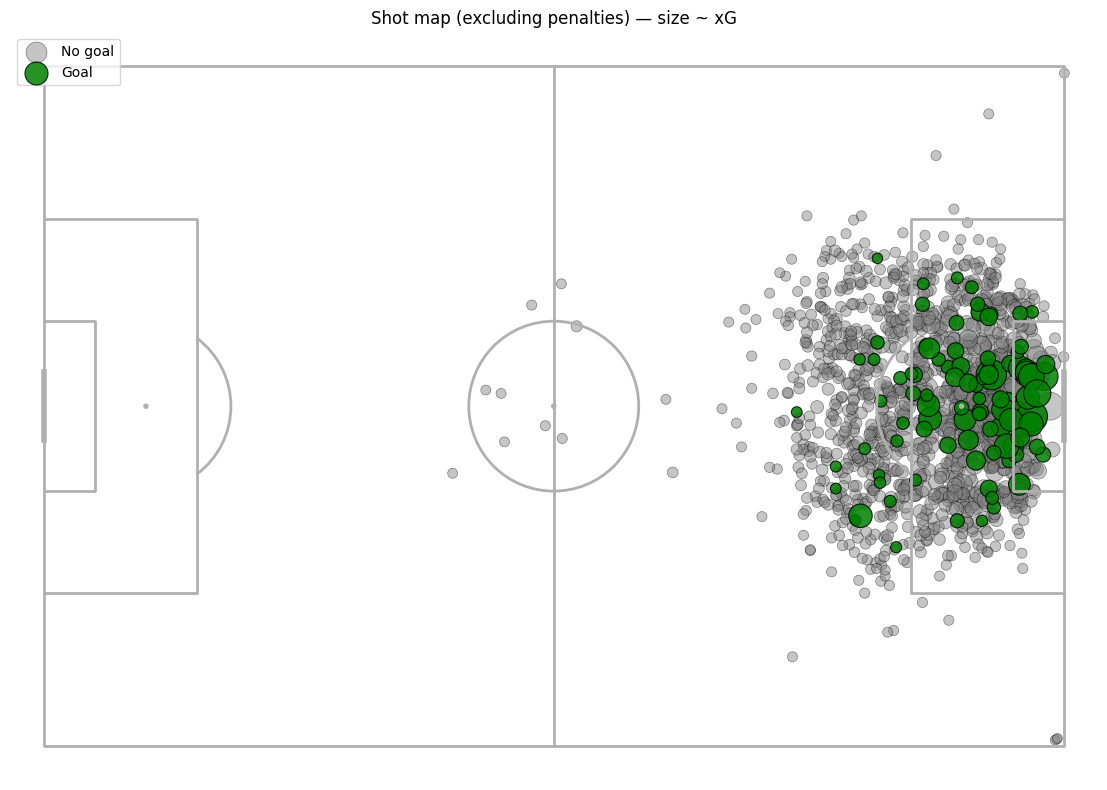

In [27]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd

# --- Filtrar tiros ---
shots = df[df["type"] == "Shot"].copy()

# --- Excluir penaltis ---
shots_no_pen = shots[shots["shot_type"] != "Penalty"].copy()

# --- Definir gol vs no gol ---
shots_no_pen["is_goal"] = shots_no_pen["shot_outcome"].eq("Goal")

# --- xG (por seguridad) ---
shots_no_pen["xg"] = (
    pd.to_numeric(shots_no_pen["shot_statsbomb_xg"], errors="coerce")
    .fillna(0.0)
)

# --- Tamaño del punto según xG ---
shots_no_pen["marker_size"] = 50 + shots_no_pen["xg"] * 500

# --- Separar goles y no goles ---
goals = shots_no_pen[shots_no_pen["is_goal"]]
nongoals = shots_no_pen[~shots_no_pen["is_goal"]]

# --- Dibujar pitch ---
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

# --- No goles ---
pitch.scatter(
    nongoals["x"], nongoals["y"],
    s=nongoals["marker_size"],
    ax=ax,
    color="gray",
    alpha=0.45,
    edgecolors="black",
    linewidth=0.5,
    label="No goal"
)

# --- Goles ---
pitch.scatter(
    goals["x"], goals["y"],
    s=goals["marker_size"],
    ax=ax,
    color="green",
    alpha=0.85,
    edgecolors="black",
    linewidth=0.8,
    label="Goal"
)

ax.set_title("Shot map (excluding penalties) — size ~ xG")
ax.legend(loc="upper left")

plt.show()


Match ID (France vs Portugal): 3942349

Equipos en el partido (según tiros):
team
France      25
Portugal    19
Name: count, dtype: int64

Tiros totales (incluyendo penaltis): 44
Penaltis excluidos: 9
Tiros sin penaltis: 35
Goles (sin penaltis): 0

Outcomes (sin penaltis):
shot_outcome
Blocked    12
Off T      10
Saved       9
Wayward     2
Post        2
Name: count, dtype: int64


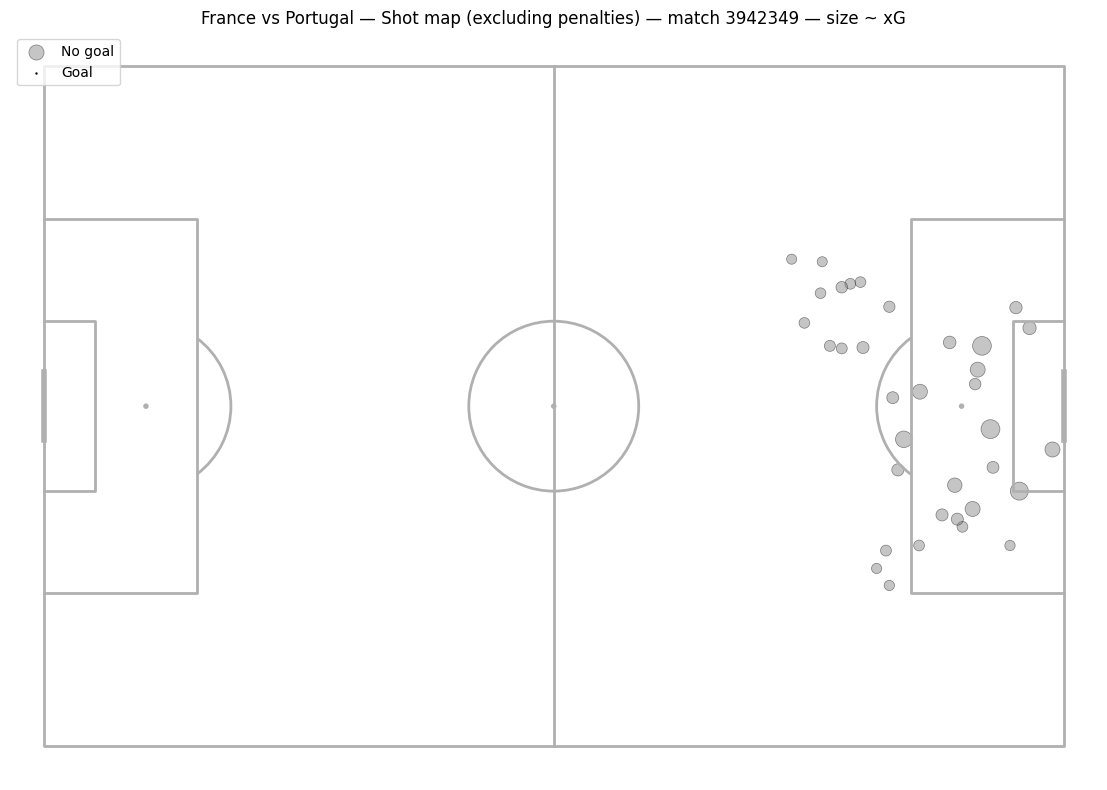

In [28]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# --- 1) Filtrar tiros del dataset ---
shots = df[df["type"] == "Shot"].copy()

# --- 2) Encontrar match_id donde aparezcan France y Portugal ---
matches_fp = (
    shots.groupby("match_id")["team"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="teams")
)

fp = matches_fp[matches_fp["teams"].apply(lambda t: {"France", "Portugal"}.issubset(t))]

if fp.empty:
    # fallback: por si tu dataset usa nombres distintos (ej. "Francia", "Portugal")
    fp = matches_fp[matches_fp["teams"].apply(lambda t: {"Francia", "Portugal"}.issubset(t))]

if fp.empty:
    raise ValueError(
        "No encuentro un match_id con France+Portugal (ni Francia+Portugal) en la columna 'team'. "
        "Mira nombres exactos con: df['team'].dropna().unique()"
    )

match_id = int(fp["match_id"].iloc[0])

# --- 3) Tiros SOLO de ese partido ---
shots_fp = shots[shots["match_id"] == match_id].copy()

# --- 4) Excluir penaltis (en juego) ---
# (si tu columna shot_type existe; si no, lo avisamos)
if "shot_type" not in shots_fp.columns:
    raise ValueError("No existe la columna 'shot_type' en tu dataset procesado. Revisa el build_dataset.")

n_pen = (shots_fp["shot_type"] == "Penalty").sum()
shots_fp_no_pen = shots_fp[shots_fp["shot_type"] != "Penalty"].copy()

# --- 5) Definir gol, xG y tamaño ---
shots_fp_no_pen["is_goal"] = shots_fp_no_pen["shot_outcome"].eq("Goal")
shots_fp_no_pen["xg"] = pd.to_numeric(shots_fp_no_pen["shot_statsbomb_xg"], errors="coerce").fillna(0.0)
shots_fp_no_pen["marker_size"] = 50 + shots_fp_no_pen["xg"] * 500

goals = shots_fp_no_pen[shots_fp_no_pen["is_goal"]]
nongoals = shots_fp_no_pen[~shots_fp_no_pen["is_goal"]]

# --- 6) Resumen rápido ---
teams_in_match = shots_fp["team"].value_counts()
print(f"Match ID (France vs Portugal): {match_id}")
print("\nEquipos en el partido (según tiros):")
print(teams_in_match)

print(f"\nTiros totales (incluyendo penaltis): {len(shots_fp)}")
print(f"Penaltis excluidos: {int(n_pen)}")
print(f"Tiros sin penaltis: {len(shots_fp_no_pen)}")
print(f"Goles (sin penaltis): {len(goals)}")

print("\nOutcomes (sin penaltis):")
print(shots_fp_no_pen["shot_outcome"].value_counts(dropna=False).head(15))

# --- 7) Plot ---
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(
    nongoals["x"], nongoals["y"],
    s=nongoals["marker_size"],
    ax=ax,
    color="gray",
    alpha=0.45,
    edgecolors="black",
    linewidth=0.5,
    label="No goal"
)

pitch.scatter(
    goals["x"], goals["y"],
    s=goals["marker_size"],
    ax=ax,
    color="green",
    alpha=0.85,
    edgecolors="black",
    linewidth=0.8,
    label="Goal"
)

ax.set_title(f"France vs Portugal — Shot map (excluding penalties) — match {match_id} — size ~ xG")
ax.legend(loc="upper left")
plt.show()


C:\Users\javie\AppData\Local\Temp\ipykernel_16916\3597095007.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(shot_types))


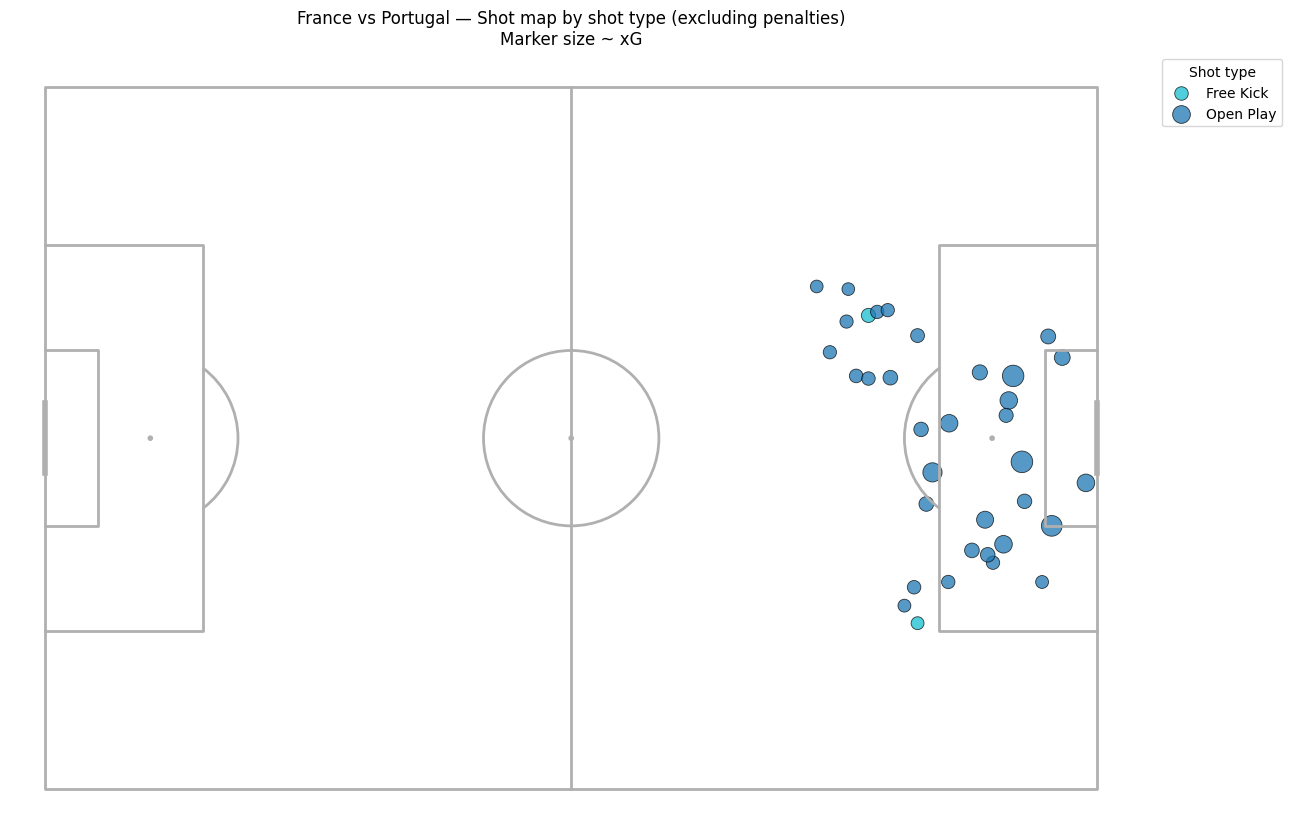

In [29]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import matplotlib.cm as cm

# --- Asumimos df ya cargado ---
shots = df[df["type"] == "Shot"].copy()

# --- Encontrar match_id France vs Portugal ---
matches_fp = (
    shots.groupby("match_id")["team"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="teams")
)

fp = matches_fp[matches_fp["teams"].apply(lambda t: {"France", "Portugal"}.issubset(t))]
match_id = int(fp["match_id"].iloc[0])

# --- Tiros del partido ---
shots_fp = shots[shots["match_id"] == match_id].copy()

# --- Excluir penaltis ---
shots_fp = shots_fp[shots_fp["shot_type"] != "Penalty"].copy()

# --- Preparar xG y tamaño ---
shots_fp["xg"] = pd.to_numeric(
    shots_fp["shot_statsbomb_xg"], errors="coerce"
).fillna(0.0)

shots_fp["marker_size"] = 80 + shots_fp["xg"] * 600

# --- Tipos de tiro presentes ---
shot_types = shots_fp["shot_type"].dropna().unique()

# --- Colormap automático ---
cmap = cm.get_cmap("tab10", len(shot_types))
color_map = {st: cmap(i) for i, st in enumerate(shot_types)}

# --- Dibujar pitch ---
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(13, 9))

# --- Plot por tipo de tiro ---
for shot_type, data in shots_fp.groupby("shot_type"):
    pitch.scatter(
        data["x"], data["y"],
        s=data["marker_size"],
        ax=ax,
        color=color_map[shot_type],
        alpha=0.75,
        edgecolors="black",
        linewidth=0.6,
        label=shot_type
    )

ax.set_title(
    f"France vs Portugal — Shot map by shot type (excluding penalties)\n"
    f"Marker size ~ xG"
)

ax.legend(
    title="Shot type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.show()


C:\Users\javie\AppData\Local\Temp\ipykernel_16916\273559818.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(vals))


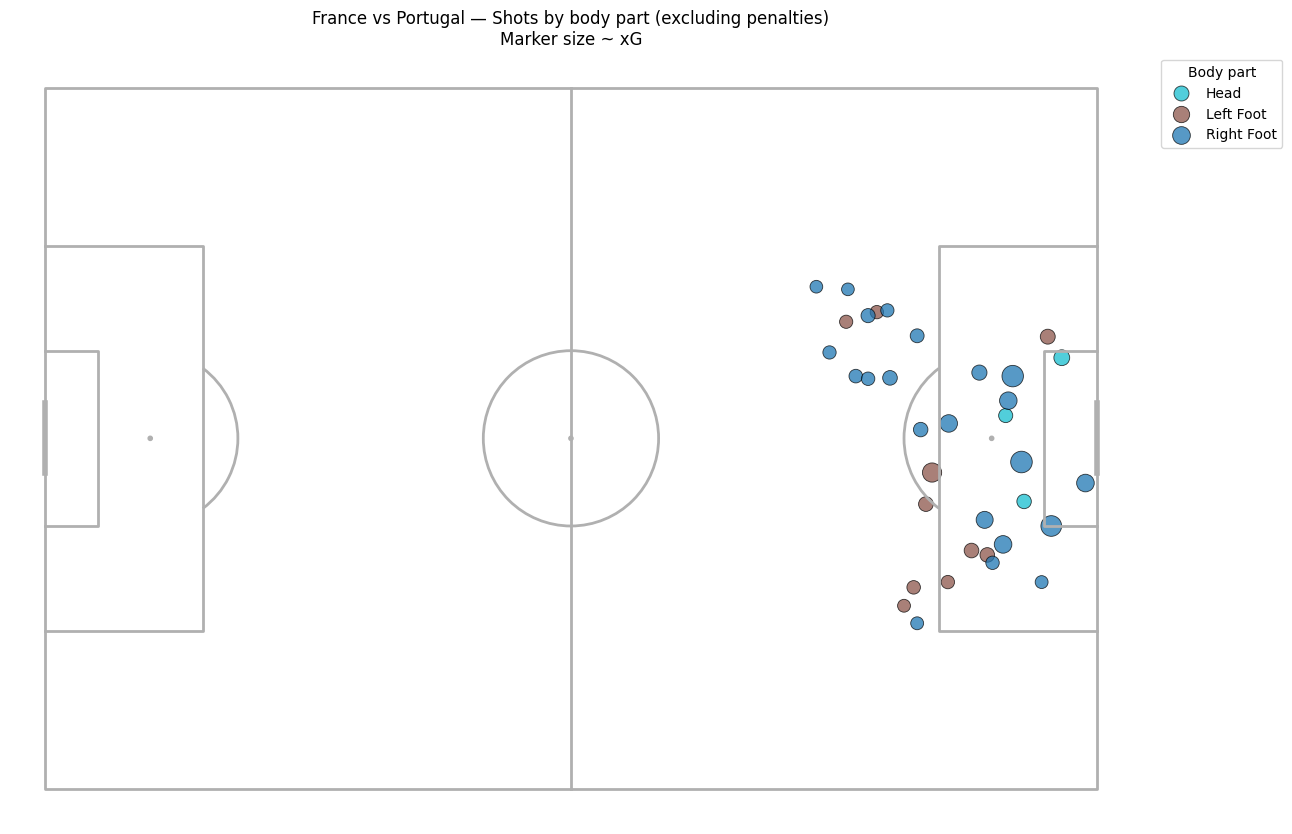

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import matplotlib.cm as cm

shots = df[df["type"] == "Shot"].copy()

# match France vs Portugal
matches_fp = (shots.groupby("match_id")["team"]
              .apply(lambda x: set(x.dropna()))
              .reset_index(name="teams"))
match_id = int(matches_fp[matches_fp["teams"].apply(lambda t: {"France","Portugal"}.issubset(t))]["match_id"].iloc[0])

shots_fp = shots[shots["match_id"] == match_id].copy()

# excluir penaltis por contexto
shots_fp = shots_fp[shots_fp["shot_type"] != "Penalty"].copy()

# tamaño por xG
shots_fp["xg"] = pd.to_numeric(shots_fp["shot_statsbomb_xg"], errors="coerce").fillna(0.0)
shots_fp["marker_size"] = 80 + shots_fp["xg"] * 600

# colores por parte del cuerpo
key = "shot_body_part"
vals = shots_fp[key].dropna().unique()
cmap = cm.get_cmap("tab10", len(vals))
color_map = {v: cmap(i) for i, v in enumerate(vals)}

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(13, 9))

for v, data in shots_fp.groupby(key):
    pitch.scatter(
        data["x"], data["y"],
        s=data["marker_size"],
        ax=ax,
        color=color_map[v],
        alpha=0.75,
        edgecolors="black",
        linewidth=0.6,
        label=v
    )

ax.set_title(f"France vs Portugal — Shots by body part (excluding penalties)\nMarker size ~ xG")
ax.legend(title="Body part", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()


Match ID (Spain vs France - semifinal): 3942752
Tiros de Lamine Yamal: 3



,minute,second,period,shot_outcome,shot_type,shot_body_part,play_pattern,shot_statsbomb_xg,x,y
178497,20,15,1,Goal,Open Play,Left Foot,From Goal Kick,0.026812,93.2,47.1
179059,39,59,1,Blocked,Open Play,Left Foot,Regular Play,0.024287,97.7,49.9
180665,80,56,2,Off T,Open Play,Left Foot,Regular Play,0.054384,100.4,51.7


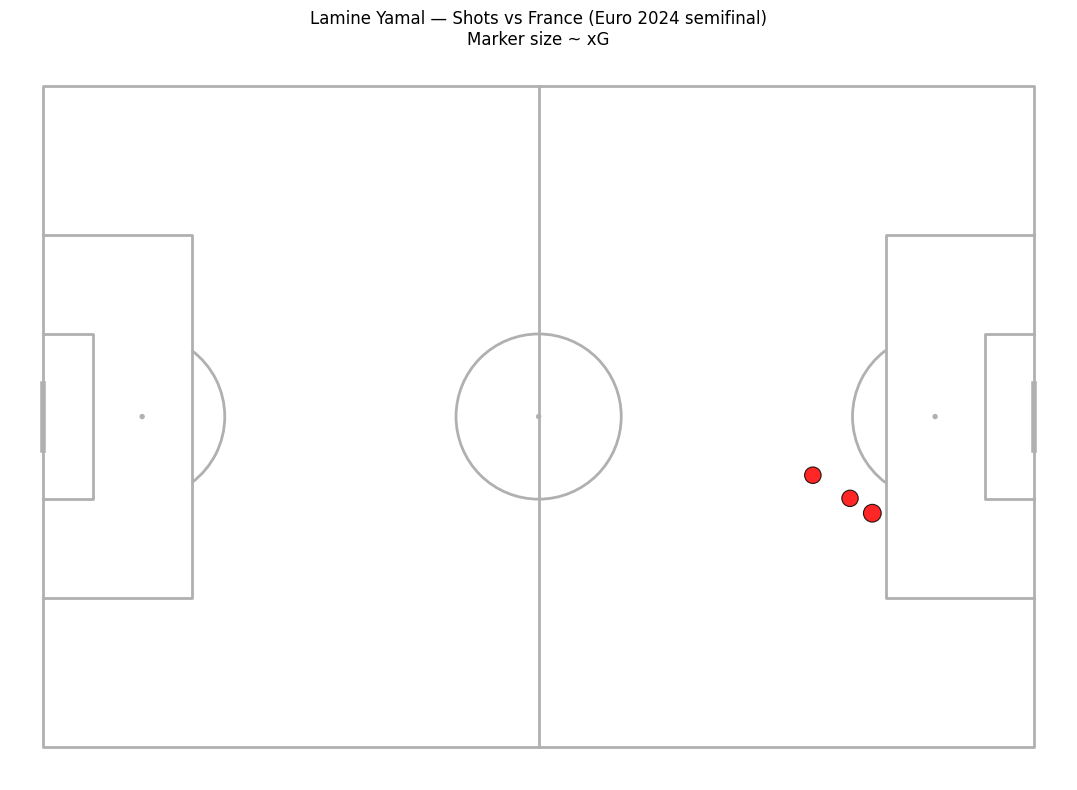

In [32]:
import pandas as pd
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# --- 1) Filtrar tiros ---
shots = df[df["type"] == "Shot"].copy()

# --- 2) Encontrar el match_id del España vs Francia ---
matches_sf = (
    shots.groupby("match_id")["team"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="teams")
)

sf = matches_sf[matches_sf["teams"].apply(lambda t: {"Spain", "France"}.issubset(t))]

if sf.empty:
    raise ValueError(
        "No encuentro un match_id con Spain y France. "
        "Comprueba nombres exactos con df['team'].unique()."
    )

match_id = int(sf["match_id"].iloc[0])

# --- 3) Filtrar tiros de Lamine Yamal en ese partido ---
lamine_shots = shots[
    (shots["match_id"] == match_id) &
    (shots["player"] == "Lamine Yamal Nasraoui Ebana")
].copy()

# --- 4) Mostrar tabla resumen ---
print(f"Match ID (Spain vs France - semifinal): {match_id}")
print(f"Tiros de Lamine Yamal: {len(lamine_shots)}\n")

display(
    lamine_shots[[
        "minute", "second", "period",
        "shot_outcome", "shot_type", "shot_body_part",
        "play_pattern", "shot_statsbomb_xg",
        "x", "y"
    ]].sort_values(["minute", "second"])
)

# --- 5) Representación gráfica (shot map) ---
lamine_shots["xg"] = (
    pd.to_numeric(lamine_shots["shot_statsbomb_xg"], errors="coerce")
    .fillna(0.0)
)
lamine_shots["marker_size"] = 120 + lamine_shots["xg"] * 800

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(
    lamine_shots["x"], lamine_shots["y"],
    s=lamine_shots["marker_size"],
    ax=ax,
    color="red",
    edgecolors="black",
    linewidth=0.8,
    alpha=0.85
)

ax.set_title(
    "Lamine Yamal — Shots vs France (Euro 2024 semifinal)\n"
    "Marker size ~ xG"
)

plt.show()


Match ID (Spain vs France - semifinal): 3942752
Nombre exacto en el dataset: <ArrowStringArray>
['Lamine Yamal Nasraoui Ebana']
Length: 1, dtype: str
Tiros totales: 3 | Goles: 1 | No gol: 2



,minute,second,period,shot_outcome,shot_type,shot_body_part,play_pattern,shot_statsbomb_xg,x,y
178497,20,15,1,Goal,Open Play,Left Foot,From Goal Kick,0.026812,93.2,47.1
179059,39,59,1,Blocked,Open Play,Left Foot,Regular Play,0.024287,97.7,49.9
180665,80,56,2,Off T,Open Play,Left Foot,Regular Play,0.054384,100.4,51.7


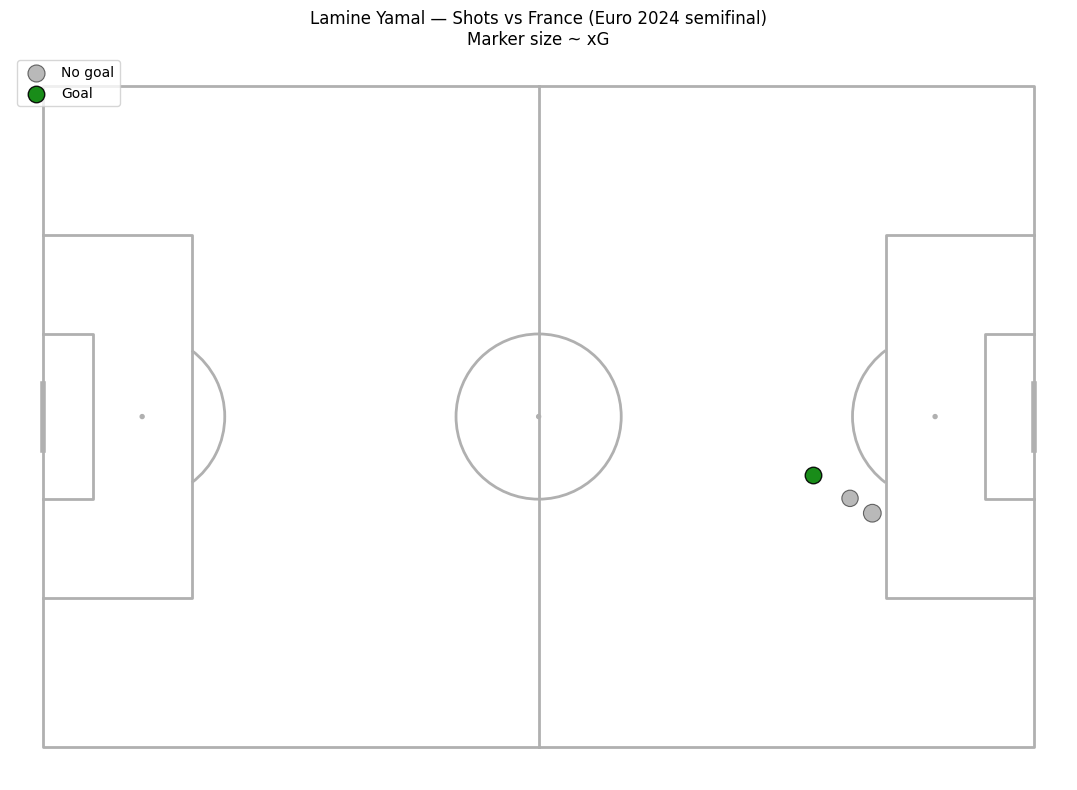

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# --- 1) Filtrar tiros ---
shots = df[df["type"] == "Shot"].copy()

# --- 2) Encontrar match_id España vs Francia ---
matches_sf = (
    shots.groupby("match_id")["team"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="teams")
)

sf = matches_sf[matches_sf["teams"].apply(lambda t: {"Spain", "France"}.issubset(t))]

if sf.empty:
    raise ValueError(
        "No encuentro el partido Spain vs France. "
        "Revisa nombres exactos con df['team'].unique()."
    )

match_id = int(sf["match_id"].iloc[0])

# --- 3) Filtrar tiros de Lamine Yamal (nombre largo) ---
lamine_shots = shots[
    (shots["match_id"] == match_id) &
    (shots["player"].str.contains("Lamine Yamal", case=False, na=False))
].copy()

if lamine_shots.empty:
    raise ValueError("No he encontrado tiros de Lamine Yamal en ese partido con el filtro actual.")

# --- 4) Separar gol / no gol ---
lamine_shots["is_goal"] = lamine_shots["shot_outcome"].eq("Goal")

goals = lamine_shots[lamine_shots["is_goal"]].copy()
nongoals = lamine_shots[~lamine_shots["is_goal"]].copy()

# --- 5) Mostrar resumen y tabla ---
print(f"Match ID (Spain vs France - semifinal): {match_id}")
print("Nombre exacto en el dataset:", lamine_shots["player"].unique())
print(f"Tiros totales: {len(lamine_shots)} | Goles: {len(goals)} | No gol: {len(nongoals)}\n")

display(
    lamine_shots[[
        "minute", "second", "period",
        "shot_outcome", "shot_type", "shot_body_part",
        "play_pattern", "shot_statsbomb_xg",
        "x", "y"
    ]].sort_values(["minute", "second"])
)

# --- 6) Preparar tamaño por xG ---
lamine_shots["xg"] = pd.to_numeric(lamine_shots["shot_statsbomb_xg"], errors="coerce").fillna(0.0)
lamine_shots["marker_size"] = 120 + lamine_shots["xg"] * 800

# Reaplicar sizes a los sub-dfs
goals = lamine_shots[lamine_shots["is_goal"]].copy()
nongoals = lamine_shots[~lamine_shots["is_goal"]].copy()

# --- 7) Plot: verde = gol, gris = no gol ---
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(
    nongoals["x"], nongoals["y"],
    s=nongoals["marker_size"],
    ax=ax,
    color="gray",
    alpha=0.55,
    edgecolors="black",
    linewidth=0.8,
    label="No goal"
)

pitch.scatter(
    goals["x"], goals["y"],
    s=goals["marker_size"],
    ax=ax,
    color="green",
    alpha=0.9,
    edgecolors="black",
    linewidth=1.0,
    label="Goal"
)

ax.set_title("Lamine Yamal — Shots vs France (Euro 2024 semifinal)\nMarker size ~ xG")
ax.legend(loc="upper left")
plt.show()
